In [1]:
import importlib
import sys
import numpy as np
from collections import Counter
import pandas as pd

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [ ]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/helpdesk.csv'

result_name = 'helpdesk_all'

# dynamic categorical attributes
cat_dynamic = ['Activity', 'Resource']

# static categorical attributes
#'VariantIndex',
cat_static =  ['VariantIndex',
               'seriousness',
               'customer',
               'product',
               'responsible_section',
               'seriousness_2',
               'service_level',
               'service_type',
               'support_section',
               'workgroup']

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day']
num_dyn_log = []

# static numeric attributes
num_static = []

min_suffix_size = 3

# validation size
train_validation_size = 0.3
# 15% test size:
test_validation_size = 0.15

event_log_properties = {# case id
                        'case_name' : 'CaseID',
                        # activity
                        'concept_name' : 'Activity',
                        # time values and computaitons
                        'timestamp_name' : 'CompleteTimestamp',
                        'date_format' : '%Y/%m/%d %H:%M:%S.%f',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # train and test split
                        'train_validation_size' : train_validation_size,
                        'test_validation_size' : test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

,CaseID,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup
0,Case 1,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1, Value 3]","[0.0, 44.0, 259959.0, 1371849.0, 2671462.0]","[nan, 44.0, 259915.0, 1111890.0, 1299613.0]","[1, 1, 4, 3, 4]","[53417, 53461, 54176, 42866, 46479]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
1,Case 2,"[Assign seriousness, Take in charge ticket, Re...","[Value 4, Value 4, Value 4, Value 5]","[0.0, 15.0, 174014.0, 3974690.0]","[nan, 15.0, 173999.0, 3800676.0]","[1, 1, 3, 5]","[32138, 32153, 33352, 32428]",1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
2,Case 3,"[Assign seriousness, Take in charge ticket, Re...","[Value 6, Value 7, Value 7, Value 5]","[0.0, 453725.0, 454031.0, 2768772.0]","[nan, 453725.0, 306.0, 2314741.0]","[4, 2, 2, 1]","[36846, 58571, 58877, 40818]",1,Value 1,Value 3,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
3,Case 4,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 2, Value 2, Value 5]","[0.0, 62954.0, 63386.0, 5098129.0]","[nan, 62954.0, 432.0, 5034743.0]","[2, 3, 3, 5]","[52313, 28867, 29299, 52842]",1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
4,Case 5,"[Assign seriousness, Take in charge ticket, Re...","[Value 9, Value 10, Value 10, Value 10, Value ...","[0.0, 2221.0, 2330.0, 3990.0, 10736.0, 4492916.0]","[nan, 2221.0, 109.0, 1660.0, 6746.0, 4482180.0]","[1, 1, 1, 1, 1, 4]","[47312, 49533, 49642, 51302, 58048, 47428]",9,Value 1,Value 5,Value 3,Value 1,Value 2,Value 3,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4575,Case 4576,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2, Value 5]","[0.0, 19.0, 4260.0, 2678905.0]","[nan, 19.0, 4241.0, 2674645.0]","[1, 1, 1, 4]","[37311, 37330, 41571, 37816]",1,Value 1,Value 68,Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
4576,Case 4577,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2, Value 5]","[0.0, 1706476.0, 1706481.0, 4298498.0]","[nan, 1706476.0, 5.0, 2592017.0]","[2, 1, 1, 3]","[55731, 34207, 34212, 34229]",1,Value 1,Value 204,Value 3,Value 6,Value 1,Value 2,Value 1,Value 5,Value 1
4577,Case 4578,"[Assign seriousness, Resolve ticket, Closed]","[Value 1, Value 1, Value 5]","[0.0, 138.0, 2678945.0]","[nan, 138.0, 2678807.0]","[2, 2, 5]","[48070, 48208, 48615]",5,Value 1,Value 51,Value 8,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
4578,Case 4579,"[Assign seriousness, Take in charge ticket, Re...","[Value 9, Value 9, Value 9, Value 5]","[0.0, 12564.0, 12576.0, 3283705.0]","[nan, 12564.0, 12.0, 3271129.0]","[0, 0, 0, 3]","[36155, 48719, 48731, 36660]",1,Value 1,Value 71,Value 3,Value 1,Value 1,Value 3,Value 1,Value 1,Value 1


In [6]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup
0,Case 2,1,[Assign seriousness],[Value 4],[0.0],[nan],[1.0],[32138.0],1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
1,Case 2,2,"[Assign seriousness, Take in charge ticket]","[Value 4, Value 4]","[0.0, 15.0]","[nan, 15.0]","[1.0, 1.0]","[32138.0, 32153.0]",1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
2,Case 2,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 4, Value 4, Value 4]","[0.0, 15.0, 174014.0]","[nan, 15.0, 173999.0]","[1.0, 1.0, 3.0]","[32138.0, 32153.0, 33352.0]",1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
3,Case 2,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 4, Value 4, Value 4, Value 5]","[0.0, 15.0, 174014.0, 3974690.0]","[nan, 15.0, 173999.0, 3800676.0]","[1.0, 1.0, 3.0, 5.0]","[32138.0, 32153.0, 33352.0, 32428.0]",1,Value 1,Value 2,Value 2,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
4,Case 3,1,[Assign seriousness],[Value 6],[0.0],[nan],[4.0],[36846.0],1,Value 1,Value 3,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11745,Case 4574,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 8, Value 8, Value 5]","[0.0, 22.0, 68724.0, 5094527.0]","[nan, 22.0, 68702.0, 5025803.0]","[3.0, 3.0, 4.0, 6.0]","[48104.0, 48126.0, 30428.0, 45031.0]",1,Value 1,Value 227,Value 2,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
11746,Case 4577,1,[Assign seriousness],[Value 2],[0.0],[nan],[2.0],[55731.0],1,Value 1,Value 204,Value 3,Value 6,Value 1,Value 2,Value 1,Value 5,Value 1
11747,Case 4577,2,"[Assign seriousness, Take in charge ticket]","[Value 2, Value 2]","[0.0, 1706476.0]","[nan, 1706476.0]","[2.0, 1.0]","[55731.0, 34207.0]",1,Value 1,Value 204,Value 3,Value 6,Value 1,Value 2,Value 1,Value 5,Value 1
11748,Case 4577,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2]","[0.0, 1706476.0, 1706481.0]","[nan, 1706476.0, 5.0]","[2.0, 1.0, 1.0]","[55731.0, 34207.0, 34212.0]",1,Value 1,Value 204,Value 3,Value 6,Value 1,Value 2,Value 1,Value 5,Value 1


In [ ]:
train_pref_df.to_csv('../../../../encoded_data_conformance_v2/Helpdesk/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [8]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup
0,Case 1,1,[Assign seriousness],[Value 1],[0.0],[nan],[1.0],[53417.0],12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
1,Case 1,2,"[Assign seriousness, Take in charge ticket]","[Value 1, Value 1]","[0.0, 44.0]","[nan, 44.0]","[1.0, 1.0]","[53417.0, 53461.0]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
2,Case 1,3,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2]","[0.0, 44.0, 259959.0]","[nan, 44.0, 259915.0]","[1.0, 1.0, 4.0]","[53417.0, 53461.0, 54176.0]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
3,Case 1,4,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1]","[0.0, 44.0, 259959.0, 1371849.0]","[nan, 44.0, 259915.0, 1111890.0]","[1.0, 1.0, 4.0, 3.0]","[53417.0, 53461.0, 54176.0, 42866.0]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
4,Case 1,5,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1, Value 3]","[0.0, 44.0, 259959.0, 1371849.0, 2671462.0]","[nan, 44.0, 259915.0, 1111890.0, 1299613.0]","[1.0, 1.0, 4.0, 3.0, 4.0]","[53417.0, 53461.0, 54176.0, 42866.0, 46479.0]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6402,Case 4579,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 9, Value 9, Value 9, Value 5]","[0.0, 12564.0, 12576.0, 3283705.0]","[nan, 12564.0, 12.0, 3271129.0]","[0.0, 0.0, 0.0, 3.0]","[36155.0, 48719.0, 48731.0, 36660.0]",1,Value 1,Value 71,Value 3,Value 1,Value 1,Value 3,Value 1,Value 1,Value 1
6403,Case 4580,1,[Take in charge ticket],[Value 6],[0.0],[nan],[1.0],[34423.0],18,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 1
6404,Case 4580,2,"[Take in charge ticket, Wait]","[Value 6, Value 6]","[0.0, 626188.0]","[nan, 626188.0]","[1.0, 1.0]","[34423.0, 55811.0]",18,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 1
6405,Case 4580,3,"[Take in charge ticket, Wait, Resolve ticket]","[Value 6, Value 6, Value 6]","[0.0, 626188.0, 632037.0]","[nan, 626188.0, 5849.0]","[1.0, 1.0, 1.0]","[34423.0, 55811.0, 61660.0]",18,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 1


In [ ]:
val_pref_df.to_csv('../../../../encoded_data_conformance_v2/Helpdesk/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [10]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup
0,Case 4,1,[Assign seriousness],[Value 8],[0.0],[nan],[2.0],[52313.0],1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
1,Case 4,2,"[Assign seriousness, Take in charge ticket]","[Value 8, Value 2]","[0.0, 62954.0]","[nan, 62954.0]","[2.0, 3.0]","[52313.0, 28867.0]",1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
2,Case 4,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 2, Value 2]","[0.0, 62954.0, 63386.0]","[nan, 62954.0, 432.0]","[2.0, 3.0, 3.0]","[52313.0, 28867.0, 29299.0]",1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
3,Case 4,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 2, Value 2, Value 5]","[0.0, 62954.0, 63386.0, 5098129.0]","[nan, 62954.0, 432.0, 5034743.0]","[2.0, 3.0, 3.0, 5.0]","[52313.0, 28867.0, 29299.0, 52842.0]",1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1
4,Case 18,1,[Assign seriousness],[Value 1],[0.0],[nan],[4.0],[57971.0],6,Value 1,Value 18,Value 4,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3186,Case 4575,1,[Assign seriousness],[Value 4],[0.0],[nan],[2.0],[52726.0],2,Value 1,Value 211,Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
3187,Case 4575,2,"[Assign seriousness, Take in charge ticket]","[Value 4, Value 2]","[0.0, 1292362.0]","[nan, 1292362.0]","[2.0, 3.0]","[52726.0, 49088.0]",2,Value 1,Value 211,Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
3188,Case 4575,3,"[Assign seriousness, Take in charge ticket, Wait]","[Value 4, Value 2, Value 9]","[0.0, 1292362.0, 1294246.0]","[nan, 1292362.0, 1884.0]","[2.0, 3.0, 3.0]","[52726.0, 49088.0, 50972.0]",2,Value 1,Value 211,Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
3189,Case 4575,4,"[Assign seriousness, Take in charge ticket, Wa...","[Value 4, Value 2, Value 9, Value 9]","[0.0, 1292362.0, 1294246.0, 1372991.0]","[nan, 1292362.0, 1884.0, 78745.0]","[2.0, 3.0, 3.0, 4.0]","[52726.0, 49088.0, 50972.0, 43317.0]",2,Value 1,Value 211,Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1


In [ ]:
test_pref_df.to_csv('../../../../encoded_data_conformance_v2/Helpdesk/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

In [12]:
# Optional set list of ids the petri net should be executed:
unique_list_train = train_pref_df["CaseID"].dropna().unique().tolist()
unique_list_val = val_pref_df["CaseID"].dropna().unique().tolist()

case_ids = list(dict.fromkeys(unique_list_train + unique_list_val))

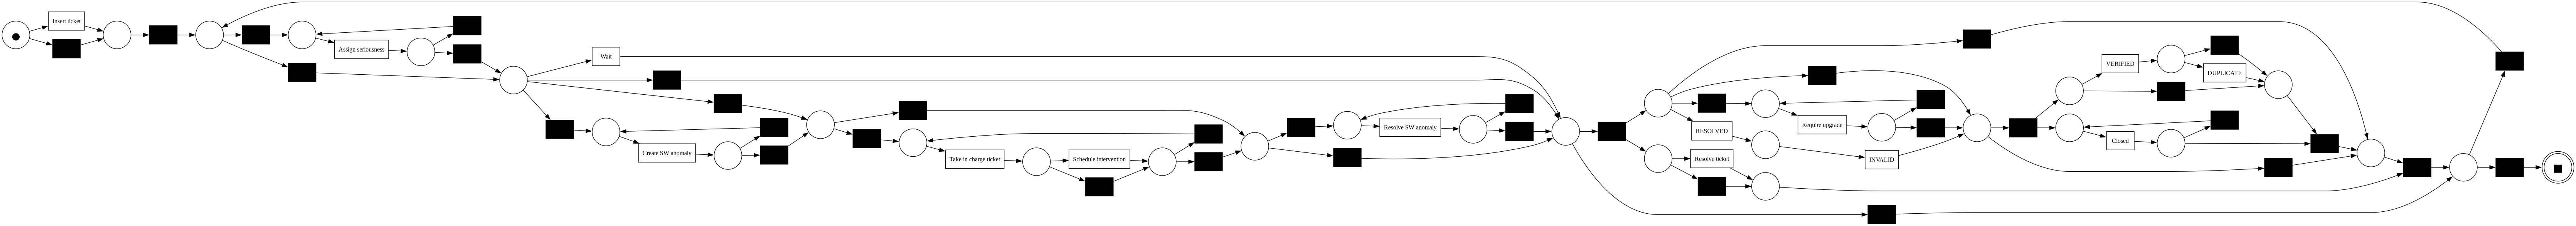

In [ ]:
# Calculate and store markings:
import os
import pickle
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="CaseID", activity_col="Activity", timestamp_col="CompleteTimestamp", resource_col="Resource")
store_loc_file_path = '../../../../encoded_data_conformance_v2/Helpdesk/prefix_for_replay/petri_net/helpdesk.png'
net, im, fm = miner.discover_petri_net(visulaize=True,
                                       case_ids=case_ids,
                                       store_loc_file_path=store_loc_file_path)

# store discovered petri net objects next to the PNG
pkl_path = os.path.splitext(store_loc_file_path)[0] + '.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump((net, im, fm), f)

In [14]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="Activity")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  11750


,marking,count
0,[p_19],2804
1,"[p_26, p_25]",2703
2,[p_9],2699
3,"[p_25, p_38, p_36]",2516
4,[p_11],812
5,"[p_24, p_30]",66
6,[p_4],54
7,"[p_30, p_25]",46
8,[p_14],32
9,[p_22],9


In [15]:
# validation set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="Activity")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  6407


,marking,count
0,[p_19],1500
1,[p_9],1499
2,"[p_26, p_25]",1459
3,"[p_25, p_38, p_36]",1369
4,[p_11],429
5,[p_4],45
6,"[p_24, p_30]",42
7,"[p_30, p_25]",30
8,[p_14],26
9,[p_18],4


In [16]:
# test set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="Activity")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  3191


,marking,count
0,[p_19],756
1,[p_9],740
2,"[p_26, p_25]",738
3,"[p_25, p_38, p_36]",687
4,[p_11],222
5,[p_4],19
6,"[p_24, p_30]",10
7,[p_14],9
8,"[p_30, p_25]",6
9,[p_22],4


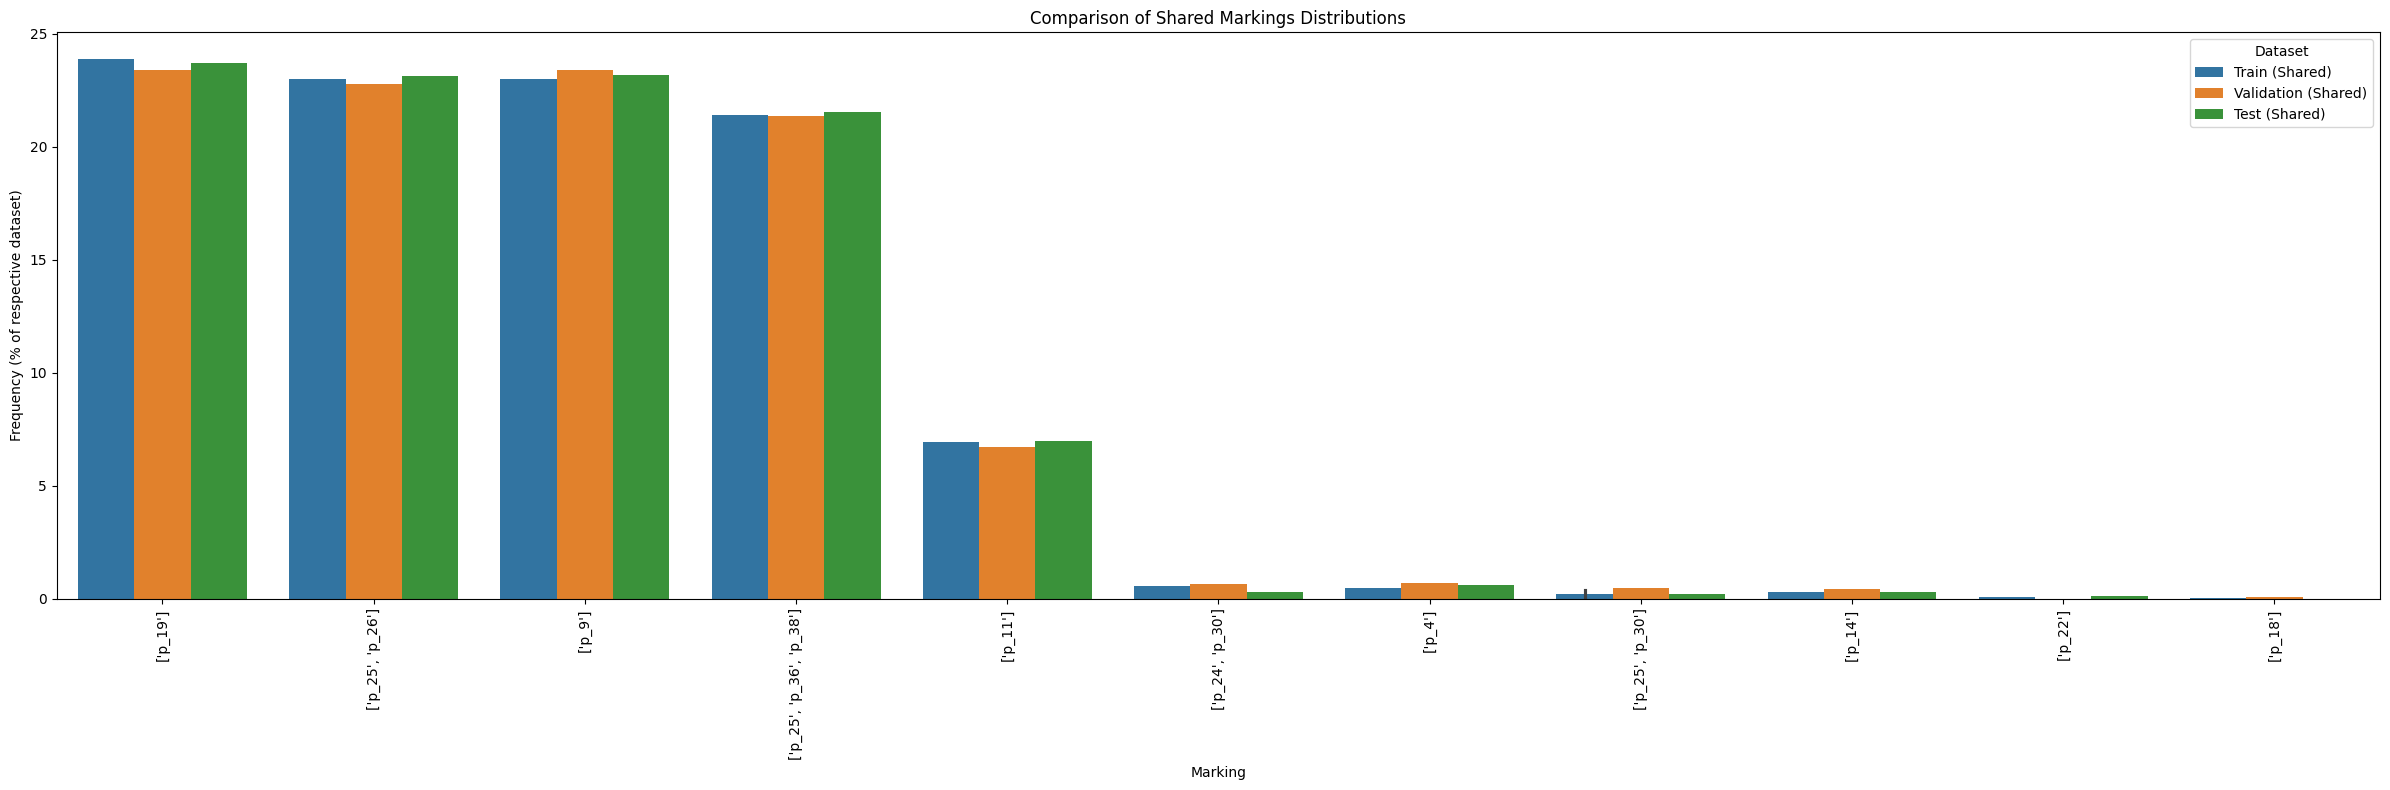

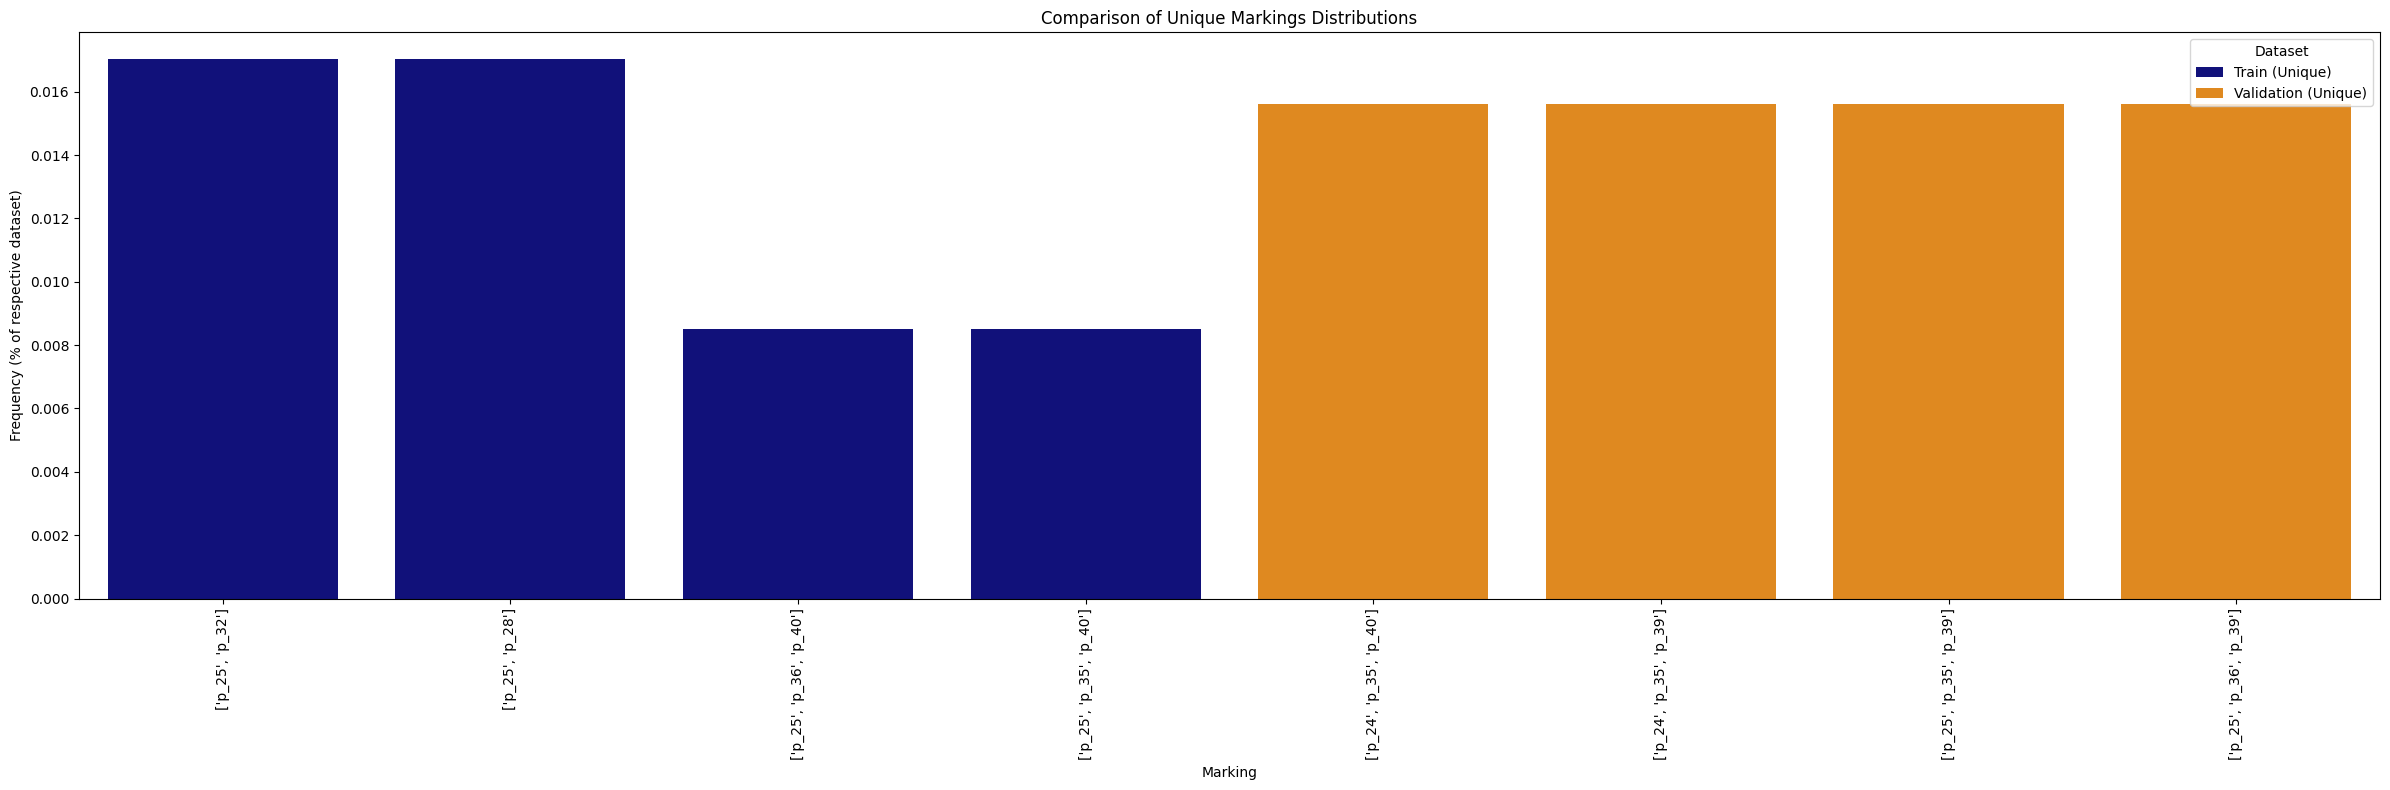

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Process train markings
markings_summary_train['marking_str'] = markings_summary_train['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_train['freq'] = (markings_summary_train['count'] / markings_summary_train['count'].sum()) * 100
markings_summary_train['dataset'] = 'Train'

# Process validation markings
markings_summary_val['marking_str'] = markings_summary_val['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_val['freq'] = (markings_summary_val['count'] / markings_summary_val['count'].sum()) * 100
markings_summary_val['dataset'] = 'Validation'

# Process test markings
markings_summary_test['marking_str'] = markings_summary_test['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_test['freq'] = (markings_summary_test['count'] / markings_summary_test['count'].sum()) * 100
markings_summary_test['dataset'] = 'Test'

# Combine
combined_markings = pd.concat([
    markings_summary_train[['marking_str', 'freq', 'dataset']],
    markings_summary_val[['marking_str', 'freq', 'dataset']], 
    markings_summary_test[['marking_str', 'freq', 'dataset']]
])

# Identify unique markings
train_markings = set(markings_summary_train['marking_str'])
val_markings = set(markings_summary_val['marking_str'])
test_markings = set(markings_summary_test['marking_str'])

def get_category(row):
    m = row['marking_str']
    d = row['dataset']
    unique = False
    if d == 'Train' and m not in val_markings and m not in test_markings:
        unique = True
    elif d == 'Validation' and m not in train_markings and m not in test_markings:
        unique = True
    elif d == 'Test' and m not in train_markings and m not in val_markings:
        unique = True
    
    return f"{d} ({'Unique' if unique else 'Shared'})"

combined_markings['category'] = combined_markings.apply(get_category, axis=1)

# Split into Shared and Unique datasets
shared_data = combined_markings[combined_markings['category'].str.contains('Shared')]
unique_data = combined_markings[combined_markings['category'].str.contains('Unique')]

# Plot 1: Shared Markings
plt.figure(figsize=(24, 8))
palette_shared = {
    'Train (Shared)': 'tab:blue',
    'Validation (Shared)': 'tab:orange', 
    'Test (Shared)': 'tab:green'
}
sns.barplot(data=shared_data, x='marking_str', y='freq', hue='category', palette=palette_shared)
plt.xticks(rotation=90)
plt.title('Comparison of Shared Markings Distributions')
plt.ylabel('Frequency (% of respective dataset)')
plt.xlabel('Marking')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Unique Markings
plt.figure(figsize=(24, 8))
palette_unique = {
    'Train (Unique)': 'darkblue',
    'Validation (Unique)': 'darkorange',
    'Test (Unique)': 'darkgreen'
}

if not unique_data.empty:
    sns.barplot(data=unique_data, x='marking_str', y='freq', hue='category', palette=palette_unique)
    plt.xticks(rotation=90)
    plt.title('Comparison of Unique Markings Distributions')
    plt.ylabel('Frequency (% of respective dataset)')
    plt.xlabel('Marking')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("No unique markings found across datasets.")

In [18]:
# Remove prefixes whose Petri net marking is unique to one split (Train/Val/Test)
"""
(train_pref_df,
val_pref_df,
test_pref_df,
markings_train,
markings_val,
markings_test,
(keep_train_ix, keep_val_ix, keep_test_ix))= pref_adopt_dataframe.remove_prefixes_with_unique_markings(train_pref_df,
                                                                                                        val_pref_df,
                                                                                                        test_pref_df,
                                                                                                        markings_train,
                                                                                                        markings_val,
                                                                                                        markings_test)

print("Kept prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))
"""

'\n(train_pref_df,\nval_pref_df,\ntest_pref_df,\nmarkings_train,\nmarkings_val,\nmarkings_test,\n(keep_train_ix, keep_val_ix, keep_test_ix))= pref_adopt_dataframe.remove_prefixes_with_unique_markings(train_pref_df,\n                                                                                                        val_pref_df,\n                                                                                                        test_pref_df,\n                                                                                                        markings_train,\n                                                                                                        markings_val,\n                                                                                                        markings_test)\n\nprint("Kept prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))\n'

## Dtore datasets and credentials for Deep-NN

In [19]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [20]:
# test
test_set = el_loader.get_encoded_dataframe(type='test')
test_set

,CaseID,Activity,Resource,CompleteTimestamp,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,Case 4,Assign seriousness,Value 8,2010-12-15 14:31:53,1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1,0.0,NaN,2.0,52313.0
1,Case 4,Take in charge ticket,Value 2,2010-12-16 08:01:07,1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1,62954.0,62954.0,3.0,28867.0
2,Case 4,Resolve ticket,Value 2,2010-12-16 08:08:19,1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1,63386.0,432.0,3.0,29299.0
3,Case 4,Closed,Value 5,2011-02-12 14:40:42,1,Value 1,Value 4,Value 3,Value 1,Value 2,Value 2,Value 1,Value 1,Value 1,5098129.0,5034743.0,5.0,52842.0
4,Case 4,EOS,EOS,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5247,Case 4575,Resolve ticket,Value 9,2013-03-22 12:01:57,2,Value 1,Value 211,Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1,1372991.0,78745.0,4.0,43317.0
5248,Case 4575,Closed,Value 3,2013-04-06 11:02:15,2,Value 1,Value 211,Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1,2665409.0,1292418.0,5.0,39735.0
5249,Case 4575,EOS,EOS,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5250,Case 4575,EOS,EOS,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# subset to prefixes that remain after unique-marking filtering (if run)
# try:
#     train_set = train_set.subset(keep_train_ix)
# except NameError:
#     pass

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data_conformance_v2/Helpdesk/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/2519 [00:00<?, ?it/s]

Resource:   0%|          | 0/2519 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/2519 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/2519 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/2519 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/2519 [00:00<?, ?it/s]

static categorical:   0%|          | 0/11750 [00:00<?, ?it/s]

In [22]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  3
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 158, {'1': 1, '10': 2, '10

In [ ]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# subset to prefixes that remain after unique-marking filtering (if run)
# try:
#     val_set = val_set.subset(keep_val_ix)
# except NameError:
#     pass

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data_conformance_v2/Helpdesk/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/1374 [00:00<?, ?it/s]

Resource:   0%|          | 0/1374 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/1374 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/1374 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/1374 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/1374 [00:00<?, ?it/s]

static categorical:   0%|          | 0/6407 [00:00<?, ?it/s]

In [24]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  3
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 158, {'1': 1, '10': 2, '10

In [ ]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# subset to prefixes that remain after unique-marking filtering (if run)
# try:
#     test_set = test_set.subset(keep_test_ix)
# except NameError:
#     pass

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data_conformance_v2/Helpdesk/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/687 [00:00<?, ?it/s]

Resource:   0%|          | 0/687 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/687 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/687 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/687 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/687 [00:00<?, ?it/s]

static categorical:   0%|          | 0/3191 [00:00<?, ?it/s]

In [26]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  3
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 158, {'1': 1, '10': 2, '10